In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchvision.transforms.functional as tvF

from mpl_toolkits.axes_grid1 import make_axes_locatable

import math

!pip install captum
from captum.attr import IntegratedGradients
from captum.attr import LayerConductance
from captum.attr import Occlusion
from captum.attr import NeuronConductance
from captum.attr import NoiseTunnel

from scipy import optimize


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.0 MB/s eta 0:00:00


In [2]:
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [3]:
def acu_cal(log_py_train, y_train, log_py_test, y_test, acu):
  acu['acu_train'].append((torch.sum(torch.argmax(log_py_train, dim=1) == y_train) / y_train.size(0)).item())
  acu['acu_test'].append((torch.sum(torch.argmax(log_py_test, dim=1) == y_test) / y_test.size(0)).item())
  acu['acu_train_STDP'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 0)] == y_train[torch.argwhere(y_train == 0)]) / y_train[torch.argwhere(y_train == 0)].size(0)).item())
  acu['acu_test_STDP'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 0)] == y_test[torch.argwhere(y_test == 0)]) / y_test[torch.argwhere(y_test == 0)].size(0)).item())
  acu['acu_train_BurstProp'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 1)] == y_train[torch.argwhere(y_train == 1)]) / y_train[torch.argwhere(y_train == 1)].size(0)).item())
  acu['acu_test_BurstProp'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 1)] == y_test[torch.argwhere(y_test == 1)]) / y_test[torch.argwhere(y_test == 1)].size(0)).item())
  acu['acu_train_BP'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 2)] == y_train[torch.argwhere(y_train == 2)]) / y_train[torch.argwhere(y_train == 2)].size(0)).item())
  acu['acu_test_BP'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 2)] == y_test[torch.argwhere(y_test == 2)]) / y_test[torch.argwhere(y_test == 2)].size(0)).item())
  acu['acu_train_NC'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 3)] == y_train[torch.argwhere(y_train == 3)]) / y_train[torch.argwhere(y_train == 3)].size(0)).item())
  acu['acu_test_NC'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 3)] == y_test[torch.argwhere(y_test == 3)]) / y_test[torch.argwhere(y_test == 3)].size(0)).item())
  return acu

In [4]:
dat_dir = '/content/drive/MyDrive/Project/PlasticityDecoding/data'
SPK = []
ptype = []
for rnum in range(0, 30):
    SPK.append(np.load(dat_dir + f'/FixedRepresentation/Spk_an_wn_{rnum}.npy'))
    ptype.append(np.load(dat_dir + f'/FixedRepresentation/Ptype_an_wn_{rnum}.npy'))

SPK = np.concatenate(SPK, axis=0)
ptype = np.concatenate(ptype, axis=0)


In [5]:
class TCNN(nn.Module):
    def __init__(self, TCNN_args):
        super(TCNN, self).__init__()
        self.Feature_detector = nn.Sequential(
            nn.Conv1d(in_channels=TCNN_args['in_channels'], out_channels=TCNN_args['out_channels'], kernel_size=TCNN_args['kernel_size']),
            nn.ReLU(),
        )
        self.Norm_Pool = nn.Sequential(
            nn.BatchNorm1d(num_features=TCNN_args['out_channels'],affine=False),
            nn.MaxPool1d(kernel_size = TCNN_args['maxpool_size']),
        )
        self.FC = nn.Sequential(
            nn.Flatten(start_dim = 1),
            nn.Linear(in_features = TCNN_args['out_channels'] * int((TCNN_args['batch_size'] - TCNN_args['kernel_size'] + 1 - 2) / TCNN_args['maxpool_size'] + 1), out_features = TCNN_args['category_num'], bias=False),
        )

    def forward(self, x):
        # print(self.Feature_detector(x).size())
        return F.log_softmax(self.FC(x),dim=1)

def kernel_init(run_TCNN, TCNN_args):
    for param in run_TCNN.Feature_detector.parameters():
        param.requires_grad = False
    run_TCNN_param = run_TCNN.state_dict()
    step = TCNN_args['kernel_size'] // 6 // TCNN_args['out_channels']
    for ii in range(0, TCNN_args['out_channels']):
        run_TCNN_param['Feature_detector.0.weight'][ii] = torch.tensor(signal.windows.gaussian(TCNN_args['kernel_size'],2 + ii * step), dtype=dtype).to(device)
    run_TCNN_param['Feature_detector.0.bias'][:] = 0.0
    run_TCNN.load_state_dict(run_TCNN_param)
    return run_TCNN

def acu_cal(log_py_train, y_train, log_py_test, y_test, acu):
    acu['acu_train'].append((torch.sum(torch.argmax(log_py_train, dim=1) == y_train) / y_train.size(0)).item())
    acu['acu_test'].append((torch.sum(torch.argmax(log_py_test, dim=1) == y_test) / y_test.size(0)).item())
    acu['acu_train_STDP'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 0)] == y_train[torch.argwhere(y_train == 0)]) / y_train[torch.argwhere(y_train == 0)].size(0)).item())
    acu['acu_test_STDP'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 0)] == y_test[torch.argwhere(y_test == 0)]) / y_test[torch.argwhere(y_test == 0)].size(0)).item())
    acu['acu_train_BurstProp'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 1)] == y_train[torch.argwhere(y_train == 1)]) / y_train[torch.argwhere(y_train == 1)].size(0)).item())
    acu['acu_test_BurstProp'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 1)] == y_test[torch.argwhere(y_test == 1)]) / y_test[torch.argwhere(y_test == 1)].size(0)).item())
    acu['acu_train_Re'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 2)] == y_train[torch.argwhere(y_train == 2)]) / y_train[torch.argwhere(y_train == 2)].size(0)).item())
    acu['acu_test_Re'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 2)] == y_test[torch.argwhere(y_test == 2)]) / y_test[torch.argwhere(y_test == 2)].size(0)).item())
    acu['acu_train_BP'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 3)] == y_train[torch.argwhere(y_train == 3)]) / y_train[torch.argwhere(y_train == 3)].size(0)).item())
    acu['acu_test_BP'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 3)] == y_test[torch.argwhere(y_test == 3)]) / y_test[torch.argwhere(y_test == 3)].size(0)).item())
    acu['acu_train_NC'].append((torch.sum(torch.argmax(log_py_train, dim=1)[torch.argwhere(y_train == 4)] == y_train[torch.argwhere(y_train == 4)]) / y_train[torch.argwhere(y_train == 4)].size(0)).item())
    acu['acu_test_NC'].append((torch.sum(torch.argmax(log_py_test, dim=1)[torch.argwhere(y_test == 4)] == y_test[torch.argwhere(y_test == 4)]) / y_test[torch.argwhere(y_test == 4)].size(0)).item())
    return acu

TCNN_args = {
    'in_channels':1,
    'out_channels':5,
    'kernel_size':500,
    'maxpool_size':125,
    'category_num':5,
    'batch_size':np.size(SPK, axis=1),
}

train_args = {
    'alpha':1e-1,
    'beta':1e0,
}

acu = {
    'acu_train':[],
    'acu_test':[],
    'acu_train_STDP':[],
    'acu_test_STDP':[],
    'acu_train_BurstProp':[],
    'acu_test_BurstProp':[],
    'acu_train_Re':[],
    'acu_test_Re':[],
    'acu_train_BP':[],
    'acu_test_BP':[],
    'acu_train_NC':[],
    'acu_test_NC':[],
}


In [6]:
def weight_gen():
    train_ind = np.unique(np.random.randint(0, np.size(SPK,axis=0), np.size(SPK,axis=0)))
    test_ind = np.setdiff1d(np.arange(0, np.size(SPK,axis=0)), train_ind)

    x_train = torch.tensor(SPK[train_ind,:], dtype=dtype).to(device).unsqueeze(dim=1)
    y_train = torch.tensor(ptype[train_ind], dtype=torch.long).to(device)

    x_test = torch.tensor(SPK[test_ind,:], dtype=dtype).to(device).unsqueeze(dim=1)
    y_test = torch.tensor(ptype[test_ind], dtype=torch.long).to(device)

    run_TCNN = TCNN(TCNN_args).to(device)
    run_TCNN = kernel_init(run_TCNN, TCNN_args)

    loss_fn = nn.NLLLoss()
    optimizer = torch.optim.Adam(run_TCNN.parameters(),lr=1e-3)

    run_TCNN.train()

    x_train1 = run_TCNN.Norm_Pool(run_TCNN.Feature_detector(x_train))
    x_test1 = run_TCNN.Norm_Pool(run_TCNN.Feature_detector(x_test))

    for epoch in range(0, 500):
        log_py_train = run_TCNN(x_train1)
        for weight in run_TCNN.FC.parameters():
            L1 = train_args['beta'] * F.l1_loss(torch.zeros_like(weight), weight)
        L = train_args['alpha'] * loss_fn(log_py_train,y_train) + L1
        optimizer.zero_grad()
        L.backward()
        optimizer.step()
        if torch.sum(torch.argmax(log_py_train, dim=1) == y_train) / y_train.size(0) > 0.85:
            break

    return run_TCNN.state_dict()['FC.1.weight'].unsqueeze(0).detach().cpu().numpy()

In [7]:
weight = []
for i in range(0, 50):
    weight.append(weight_gen())

weight = np.mean(np.concatenate(weight), axis=0)

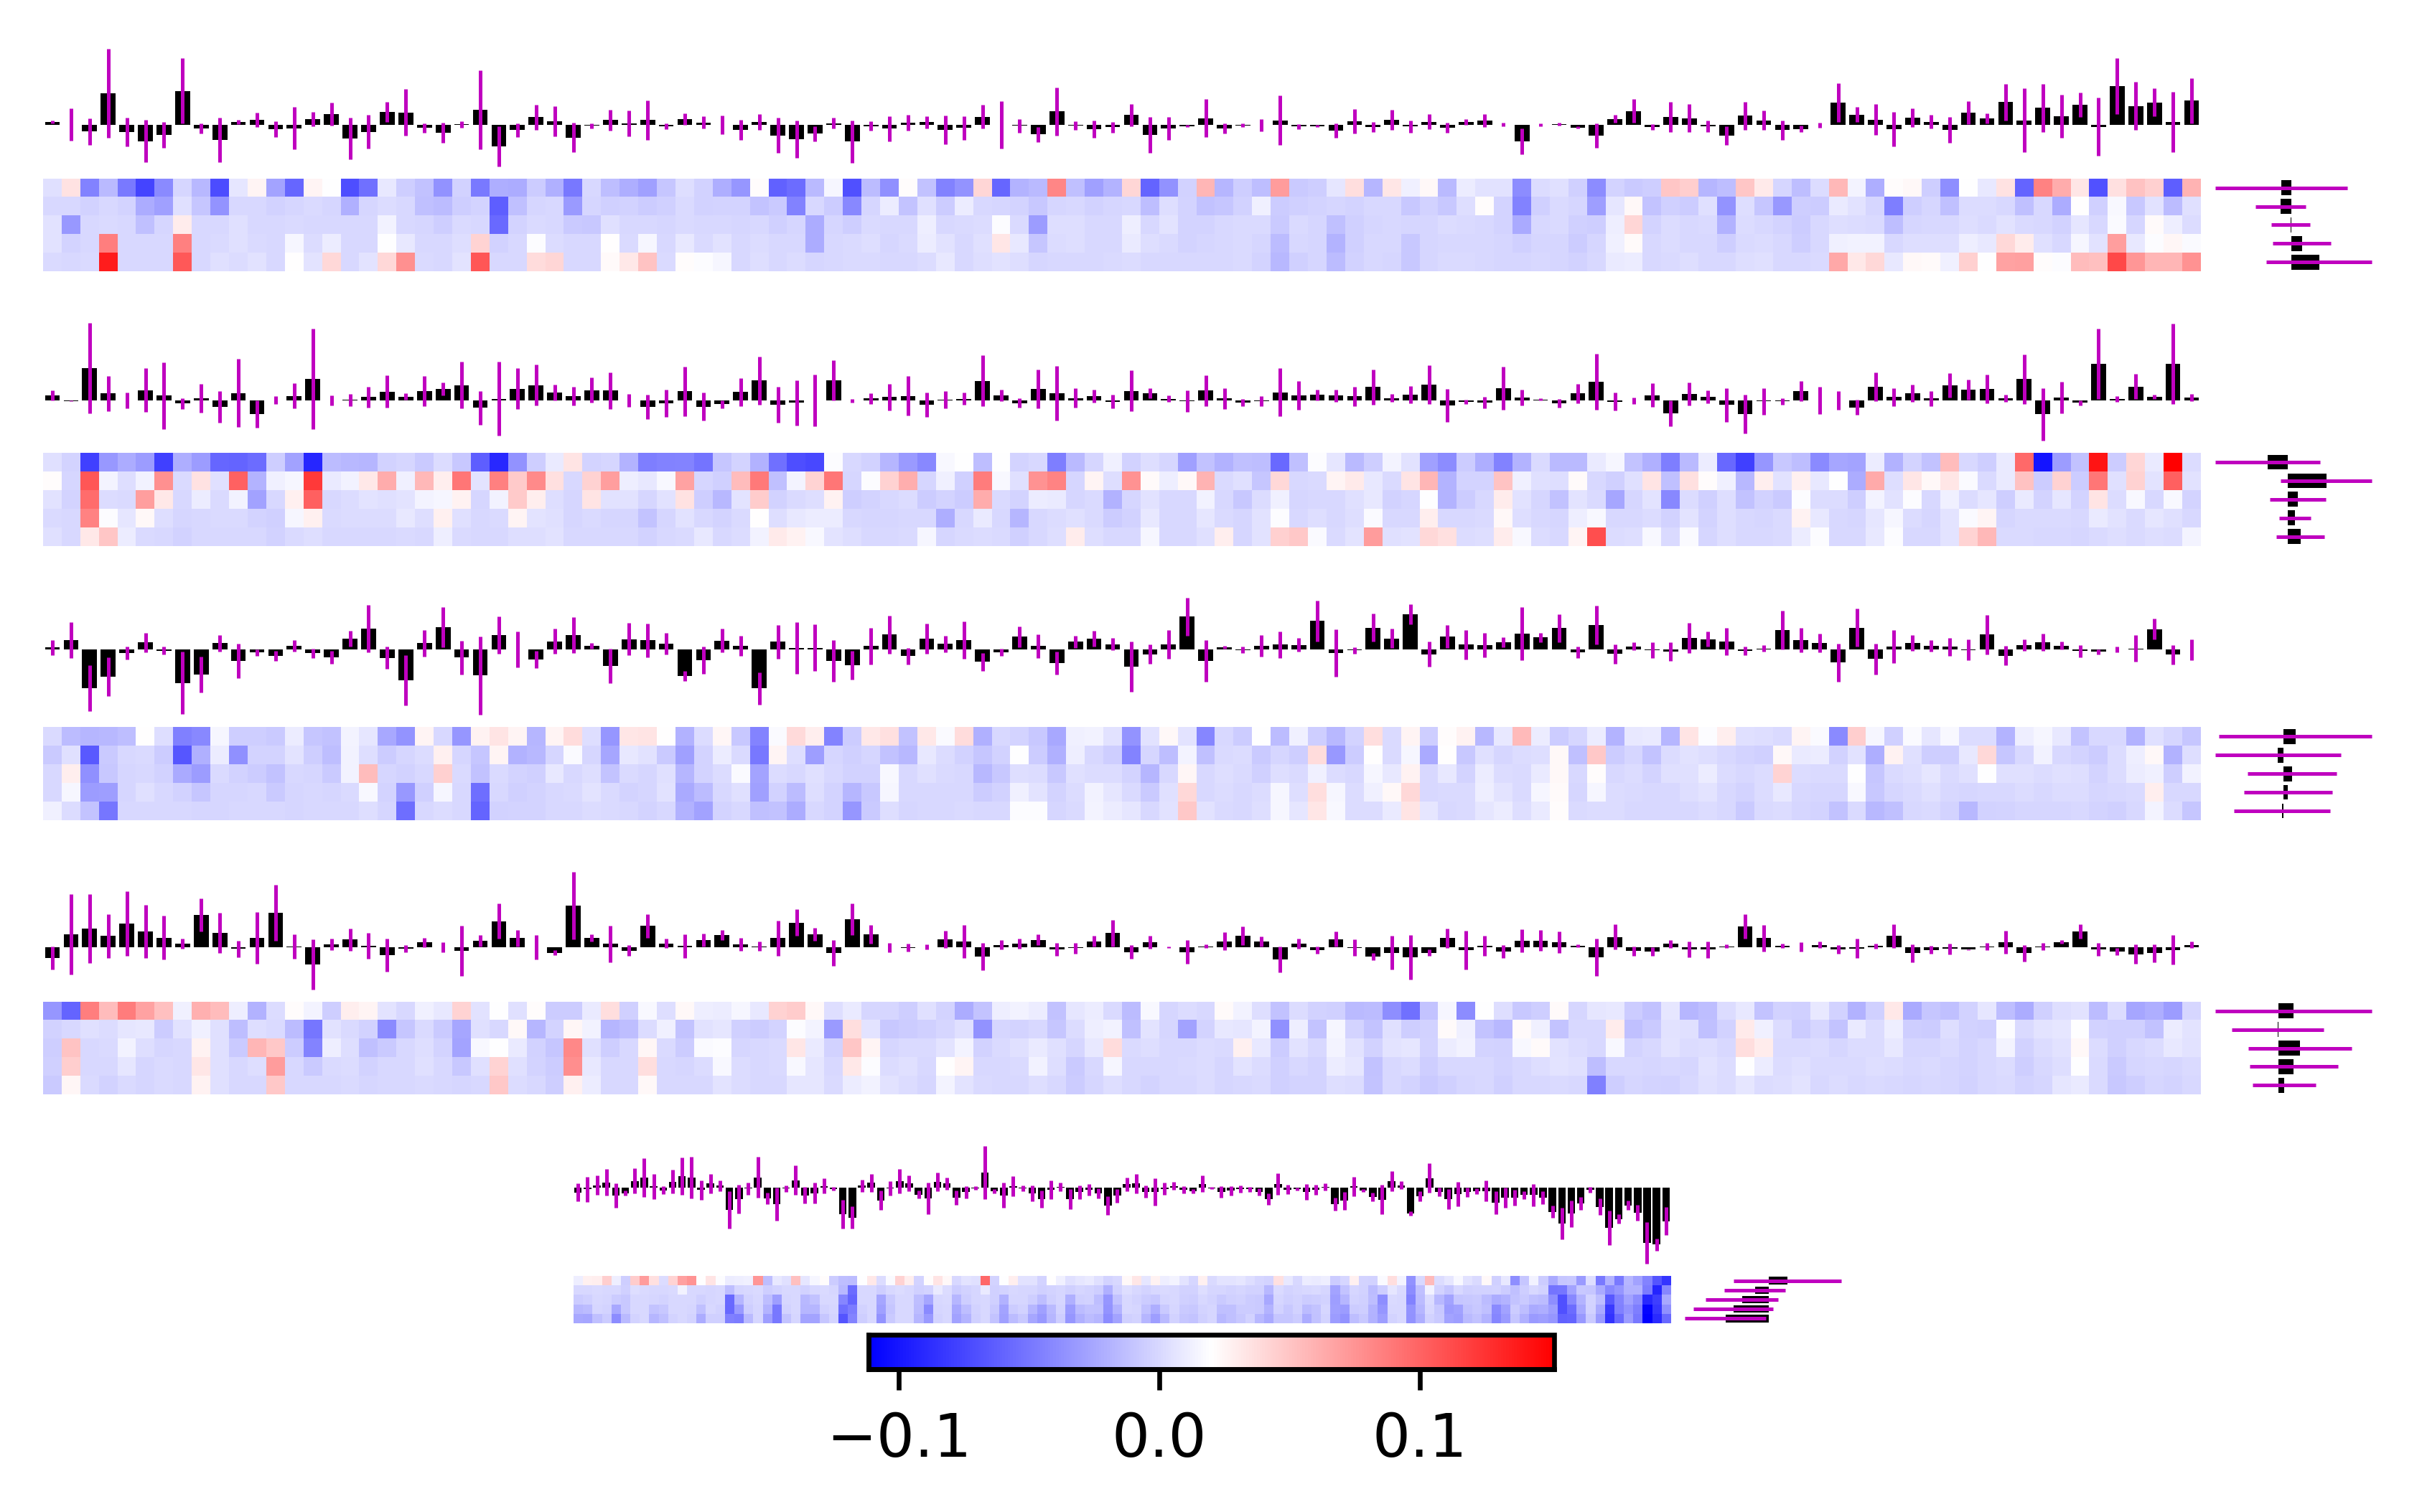

In [13]:
error_kw = {
    'elinewidth':0.6,
}
lim_min = weight.min()
lim_max = weight.max()
fig, ax = plt.subplots(5,1,figsize=(7,4),dpi=600)
for ii in range(0, TCNN_args['category_num']):
    x_m = weight.reshape(5,TCNN_args['out_channels'],-1)[ii,:,:].mean(axis=0)
    x_std = weight.reshape(5,TCNN_args['out_channels'],-1)[ii,:,:].std(axis=0)
    y_m = weight.reshape(5,TCNN_args['out_channels'],-1)[ii,:,:].mean(axis=1)
    y_std = weight.reshape(5,TCNN_args['out_channels'],-1)[ii,:,:].std(axis=1)
    im = ax[ii].imshow(weight.reshape(5,TCNN_args['out_channels'],-1)[ii,:,:],
                       cmap='bwr',vmin=lim_min, vmax=lim_max)
    if ii == TCNN_args['category_num'] - 1:
        plt.colorbar(im, ax=ax[ii], orientation='horizontal', pad = 0.05, shrink=0.3)
    # ax[ii].set_aspect(1.)
    divider = make_axes_locatable(ax[ii])
    ax_histx = divider.append_axes('top', 0.3, pad=0.015, sharex=ax[ii])
    ax_histy = divider.append_axes('right', 0.4, pad=0.015, sharey=ax[ii])
    ax_histx.xaxis.set_tick_params(labelbottom=False)
    ax_histy.yaxis.set_tick_params(labelleft=False)
    ax_histx.bar(range(0,len(x_m)), x_m, yerr=x_std, linewidth=0.1, color = 'k', ecolor='m', error_kw=error_kw)
    # ax_histx.errorbar(range(0,len(x_m)), x_m, yerr=x_std, fmt='', linewidth=0.25, color = 'b')
    # ax_histx.set_ylim(lim_min,lim_max)
    ax_histx.axis('off')
    ax_histy.barh(range(0,len(y_m)), y_m, xerr=y_std, linewidth=0.1, color = 'k', ecolor='m', error_kw=error_kw)
    # ax_histy.errorbar(range(0,len(y_m)), y_m, xerr=y_std, fmt='', linewidth=0.25, color = 'b')
    # ax_histy.set_xlim(lim_min,lim_max)
    ax_histy.axis('off')
    ax[ii].axis('off')
    sns.despine()


In [9]:
# plt.figure(dpi=600)
# plt.imshow(np.linspace(lim_min, lim_max, 100), 100)